In [2]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l
import matplotlib.pyplot as plt

### Exercise 1

What happens if you change the dropout probabilities for the first and second layers? In particular, what happens if you switch the ones for both layers? Design an experiment to answer these questions, describe your results quantitatively, and summarize the qualitative takeaways.

In [13]:
class DropoutMLP(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens_1, num_hiddens_2,
                 dropout_1, dropout_2, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(num_hiddens_1), nn.ReLU(),
            nn.Dropout(dropout_1),
            nn.LazyLinear(num_hiddens_2), nn.ReLU(),
            nn.Dropout(dropout_2),
            nn.LazyLinear(num_outputs)
        )

In [ ]:
dropout_configs = [
    (0.5, 0.5),
    (0.2, 0.5),
    (0.5, 0.2),
    (0.1, 0.5),
    (0.5, 0.1),
]

results = []
data = d2l.FashionMNIST(batch_size=256)

for d1, d2 in dropout_configs:
    hparams = {
        'num_outputs': 10,
        'num_hiddens_1': 256,
        'num_hiddens_2': 256,
        'dropout_1': d1,
        'dropout_2': d2,
        'lr': 0.1
    }

    model = DropoutMLP(**hparams)
    model.board.display = False   # no plot only keep the metrics
    trainer = d2l.Trainer(max_epochs=10)
    trainer.fit(model, data)

    final_train_loss = model.board.data['train_loss'][-1].y
    final_val_loss = model.board.data['val_loss'][-1].y
    final_val_acc = model.board.data['val_acc'][-1].y
    

    results.append({
        'dropout_1': d1,
        'dropout_2': d2,
        'train_loss': final_train_loss,
        'val_loss': final_val_loss,
        'val_acc': final_val_acc,
    })

for r in results:
    print(r)

{'dropout_1': 0.5, 'dropout_2': 0.5, 'train_loss': 0.4152290013610807, 'val_loss': 0.4199415076524019, 'val_acc': 0.84228515625}
{'dropout_1': 0.2, 'dropout_2': 0.5, 'train_loss': 0.3873010896719419, 'val_loss': 0.38390261568129064, 'val_acc': 0.86279296875}
{'dropout_1': 0.5, 'dropout_2': 0.2, 'train_loss': 0.39141399840004426, 'val_loss': 0.41141343042254447, 'val_acc': 0.8509765625}
{'dropout_1': 0.1, 'dropout_2': 0.5, 'train_loss': 0.38277994389207953, 'val_loss': 0.4036473989486694, 'val_acc': 0.8505859375}
{'dropout_1': 0.5, 'dropout_2': 0.1, 'train_loss': 0.3930793531939515, 'val_loss': 0.3897127341479063, 'val_acc': 0.8587890625}


### Exercise 2

Increase the number of epochs and compare the results obtained when using dropout with those when not using it.

In [19]:
class DropoutMLP(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens_1, num_hiddens_2,
                 dropout_1, dropout_2, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(num_hiddens_1), nn.ReLU(),
            nn.Dropout(dropout_1),
            nn.LazyLinear(num_hiddens_2), nn.ReLU(),
            nn.Dropout(dropout_2),
            nn.LazyLinear(num_outputs)
        )

In [20]:
def run_experiment(dropout_1, dropout_2, max_epochs=50):
    hparams = {
        'num_outputs': 10,
        'num_hiddens_1': 256,
        'num_hiddens_2': 256,
        'dropout_1': dropout_1,
        'dropout_2': dropout_2,
        'lr': 0.1
    }
    
    model = DropoutMLP(**hparams)
    model.board.display = False
    data = d2l.FashionMNIST(batch_size=256)
    trainer = d2l.Trainer(max_epochs=max_epochs)
    trainer.fit(model, data)
    
    return model

In [21]:
model_no_dropout = run_experiment(0.0, 0.0, max_epochs=100)
model_with_dropout = run_experiment(0.2, 0.5, max_epochs=100)

In [22]:
print("No dropout:")
print("train_loss =", model_no_dropout.board.data['train_loss'][-1].y)
print("val_loss   =", model_no_dropout.board.data['val_loss'][-1].y)
print("val_acc    =", model_no_dropout.board.data['val_acc'][-1].y)

print("\nWith dropout:")
print("train_loss =", model_with_dropout.board.data['train_loss'][-1].y)
print("val_loss   =", model_with_dropout.board.data['val_loss'][-1].y)
print("val_acc    =", model_with_dropout.board.data['val_acc'][-1].y)

No dropout:
train_loss = 0.08958432307610145
val_loss   = 0.6028107553720474
val_acc    = 0.853515625

With dropout:
train_loss = 0.16089008570226848
val_loss   = 0.3268868954852223
val_acc    = 0.897265625


### Exercise 3

What is the variance of the activations in each hidden layer when dropout is and is not applied? Draw a plot to show how this quantity evolves over time for both models.

In dropout, assume dropout rate for a certain layer is $p$, then we have
$$
\tilde{h}=\frac{m \odot h}{q}
$$
Then, according to the law of total variance
$$
\operatorname{Var}(\tilde{h})=\mathbb{E}_x[\operatorname{Var}(\tilde{h} \mid x)]+\operatorname{Var}_x(\mathbb{E}[\tilde{h} \mid x])
$$
The first term is the dropout noise
$$
\operatorname{Var}(\tilde{h} \mid x)=h(x)^2 \cdot \operatorname{Var}(\frac{m}{q}) = h(x)^2 \cdot \frac{p}{q}
$$
The second term is the data variance
$$
\mathbb{E}[\tilde{h} \mid x]=h(x)
$$
So
$$
\operatorname{Var}_x(\mathbb{E}[\tilde{h} \mid x])=\operatorname{Var}_x(h(x))
$$
This is the variance without the dropout. Combine together, we have
$$
\operatorname{Var}(\tilde{h})=\operatorname{Var}(h)+\mathbb{E}\left[h^2\right] \cdot \frac{p}{q}
$$

In [44]:
class DropoutMLP(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens_1, num_hiddens_2,
                 dropout_1, dropout_2, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(num_hiddens_1), nn.ReLU(),
            nn.Dropout(dropout_1),
            nn.LazyLinear(num_hiddens_2), nn.ReLU(),
            nn.Dropout(dropout_2),
            nn.LazyLinear(num_outputs)
        )

In [45]:
def activation_variance_of_batch(model, X, train_mode=True):
    """
    Return variance of post-dropout activations in hidden layer 1 and 2
    on a single batch X.
    """
    if train_mode:
        model.train()
    else:
        model.eval()

    activations = {}

    def save_output(name):
        def hook(module, inp, out):
            activations[name] = out.detach()    # save the output of the layer; detach() to avoid tracking gradients
        return hook

    # net[3] = first Dropout, net[6] = second Dropout
    h1 = model.net[3].register_forward_hook(save_output('h1'))  # register a hook to save the output of the first Dropout layer
    h2 = model.net[6].register_forward_hook(save_output('h2'))

    with torch.no_grad():
        _ = model(X)    # forward pass to trigger the hooks and save the activations

    h1.remove() # remove the hooks after use to avoid side effects in future forward passes; will not remove dict entries, so we can still access activations['h1'] and activations['h2']
    h2.remove()

    var1 = activations['h1'].var(unbiased=False).item()
    var2 = activations['h2'].var(unbiased=False).item()

    return var1, var2

In [46]:
def train_one_epoch(model, train_loader, optimizer):
    model.train()
    for X, y in train_loader:
        optimizer.zero_grad()
        y_hat = model(X)
        loss = model.loss(y_hat, y)
        loss.backward()
        optimizer.step()

In [47]:
def run_variance_experiment(dropout_1, dropout_2, num_epochs=20, lr=0.1):
    data = d2l.FashionMNIST(batch_size=256)

    model = DropoutMLP(
        num_outputs=10,
        num_hiddens_1=256,
        num_hiddens_2=256,
        dropout_1=dropout_1,
        dropout_2=dropout_2,
        lr=lr
    )

    # initialize lazy layers
    X0, _ = next(iter(data.train_dataloader()))
    model(X0)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    # fix probe batch for consistency across epochs; we want to see how the same batch's activations evolve during training
    probe_X, _ = next(iter(data.val_dataloader()))

    hist = {
        'epoch': [],
        'h1_var_trainmode': [],
        'h2_var_trainmode': [],
        'h1_var_evalmode': [],
        'h2_var_evalmode': [],
    }

    for epoch in range(num_epochs):
        train_one_epoch(model, data.train_dataloader(), optimizer)

        # dropout active
        v1_train, v2_train = activation_variance_of_batch(
            model, probe_X, train_mode=True
        )

        # dropout inactive
        v1_eval, v2_eval = activation_variance_of_batch(
            model, probe_X, train_mode=False
        )

        hist['epoch'].append(epoch + 1)
        hist['h1_var_trainmode'].append(v1_train)
        hist['h2_var_trainmode'].append(v2_train)
        hist['h1_var_evalmode'].append(v1_eval)
        hist['h2_var_evalmode'].append(v2_eval)

    return model, hist

In [48]:
model_no_dropout, hist_no = run_variance_experiment(
    dropout_1=0.0, dropout_2=0.0, num_epochs=20, lr=0.1
)

model_dropout, hist_drop = run_variance_experiment(
    dropout_1=0.5, dropout_2=0.5, num_epochs=20, lr=0.1
)

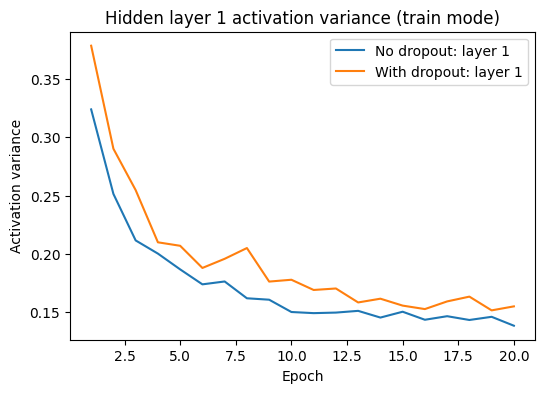

In [49]:
plt.figure(figsize=(6, 4))
plt.plot(hist_no['epoch'], hist_no['h1_var_trainmode'], label='No dropout: layer 1')
plt.plot(hist_drop['epoch'], hist_drop['h1_var_trainmode'], label='With dropout: layer 1')
plt.xlabel('Epoch')
plt.ylabel('Activation variance')
plt.title('Hidden layer 1 activation variance (train mode)')
plt.legend()
plt.show()

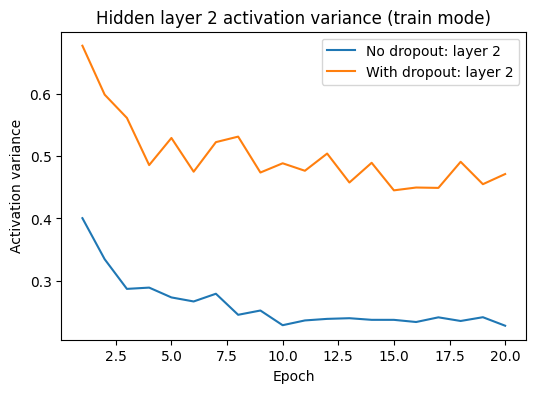

In [50]:
plt.figure(figsize=(6, 4))
plt.plot(hist_no['epoch'], hist_no['h2_var_trainmode'], label='No dropout: layer 2')
plt.plot(hist_drop['epoch'], hist_drop['h2_var_trainmode'], label='With dropout: layer 2')
plt.xlabel('Epoch')
plt.ylabel('Activation variance')
plt.title('Hidden layer 2 activation variance (train mode)')
plt.legend()
plt.show()

### Exercise 4

Why is dropout not typically used at test time?

Dropout is not typically used at test time because it introduces randomness into the network by randomly dropping units. This leads to unstable and inconsistent predictions for the same input. During training, dropout acts as a regularizer by effectively training an ensemble of subnetworks. At test time, instead of sampling these subnetworks, we use the full network with appropriately scaled weights, which approximates the average prediction of all subnetworks. This yields a deterministic and more stable prediction.

### Exercise 5

Using the model in this section as an example, compare the effects of using dropout and weight decay. What happens when dropout and weight decay are used at the same time? Are the results additive? Are there diminished returns (or worse)? Do they cancel each other out?

In [3]:
class DropoutMLP(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens_1, num_hiddens_2,
                 dropout_1, dropout_2, lr, wd):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(num_hiddens_1), nn.ReLU(),
            nn.Dropout(dropout_1),
            nn.LazyLinear(num_hiddens_2), nn.ReLU(),
            nn.Dropout(dropout_2),
            nn.LazyLinear(num_outputs)
        )

    def configure_optimizers(self):
        return torch.optim.SGD(
            self.parameters(), lr=self.lr, weight_decay=self.wd
        )   # We can use self.parameters() here because the layers have already been initialized in the constructor and registered as submodules, so their parameters are included in self.parameters().

In [4]:
configs = [
    # (dropout_1, dropout_2, wd)
    (0.0, 0.0, 0.0),        # baseline
    (0.5, 0.5, 0.0),        # dropout only
    (0.0, 0.0, 1e-4),       # weight decay only
    (0.5, 0.5, 1e-4),       # both
]

In [5]:
def evaluate_accuracy(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in dataloader:
            y_hat = model(X)
            preds = y_hat.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.numel()
    return correct / total

results = []
data = d2l.FashionMNIST(batch_size=256)

for d1, d2, wd in configs:
    hparams = {
        'num_outputs': 10,
        'num_hiddens_1': 256,
        'num_hiddens_2': 256,
        'dropout_1': d1,
        'dropout_2': d2,
        'wd': wd,
        'lr': 0.1
    }

    model = DropoutMLP(**hparams)
    model.board.display = False   # no plot only keep the metrics
    trainer = d2l.Trainer(max_epochs=30)
    trainer.fit(model, data)

    final_val_acc = model.board.data['val_acc'][-1].y
    final_train_acc = evaluate_accuracy(model, data.train_dataloader())

    results.append({
        'dropout_1': d1,
        'dropout_2': d2,
        'wd': wd,
        'train_acc': final_train_acc,
        'val_acc': final_val_acc,
    })

for r in results:
    print(r)

/Users/zouminghao/Desktop/d2l-notes-exercises/venv/lib/python3.11/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


{'dropout_1': 0.0, 'dropout_2': 0.0, 'wd': 0.0, 'train_acc': 0.9006, 'val_acc': 0.87158203125}
{'dropout_1': 0.5, 'dropout_2': 0.5, 'wd': 0.0, 'train_acc': 0.9006833333333333, 'val_acc': 0.87958984375}
{'dropout_1': 0.0, 'dropout_2': 0.0, 'wd': 0.0001, 'train_acc': 0.8960833333333333, 'val_acc': 0.8654296875}
{'dropout_1': 0.5, 'dropout_2': 0.5, 'wd': 0.0001, 'train_acc': 0.8992166666666667, 'val_acc': 0.87685546875}


### Exercise 6

What happens if we apply dropout to the individual weights of the weight matrix rather than the activations?

If dropout is applied to the weights rather than the activations, the resulting method is similar to DropConnect, where each weight is randomly set to zero. Compared to standard dropout, which removes entire activations (neurons), weight dropout removes individual connections. This leads to a more fine-grained and unstructured form of noise, which can make optimization more difficult. The resulting network becomes highly irregular and the signal propagation is less stable. As a result, training can be slower and less reliable, and performance may degrade due to excessive variance. While this method can still act as a form of regularization, it is generally less effective and less commonly used than standard dropout.